In [1]:
# Завдання 1
# У цьому завданні вам потрібно завантажити ось цей датасет. Тут ви знайдете 2 файли - з двовимірним датасетом та датасетом mnist. 
# Для кожного з них застосуйте алгоритм K-means для кластеризації. Щоб знайти оптимальну кількість кластерів, скористайтесь ліктевим методом.

In [2]:
# Завдання 2
# Візуалізуйте результат роботи кластеризації. 
# Для випадку з mnist датасетом, вам потрібно ще скористатись алгоритмом PCA щоб зменшити розмірність вашим даних до 2-вимірного варіанту.

In [3]:
import pandas as pd
import numpy as np

In [4]:
# первый датасет 2d
df_2d = pd.read_csv('data_2d.csv', header=None) # не брать первую строку в заголовок столбцов
df_2d

,0,1,2
0,0.0,-0.768716,0.460860
1,0.0,2.687848,2.366961
2,0.0,-0.201379,0.470430
3,0.0,0.608496,1.225400
4,0.0,-0.082282,1.137218
...,...,...,...
195,1.0,0.629144,4.378584
196,1.0,-0.723824,5.361801
197,1.0,1.346107,2.333476
198,1.0,3.608219,3.411546


In [5]:
df_2d.columns

Index([0, 1, 2], dtype='int64')

In [6]:
X_2d = df_2d.iloc[:, 1:] # : - взять все строки; 1: - взять столбцы с позиции 1 и дальше.
X_2d

,1,2
0,-0.768716,0.460860
1,2.687848,2.366961
2,-0.201379,0.470430
3,0.608496,1.225400
4,-0.082282,1.137218
...,...,...
195,0.629144,4.378584
196,-0.723824,5.361801
197,1.346107,2.333476
198,3.608219,3.411546


In [7]:
# второй датасет mnist
df_mnist = pd.read_csv('mnist.csv', header=None) # не брать первую строку в заголовок столбцов
df_mnist

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
496,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
497,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
df_mnist.columns

Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       775, 776, 777, 778, 779, 780, 781, 782, 783, 784],
      dtype='int64', length=785)

In [9]:
X_mnist = df_mnist.iloc[:, 1:] # : - взять все строки; 1: - взять столбцы с позиции 1 и дальше.
X_mnist

,1,2,3,4,5,6,7,8,9,10,...,775,776,777,778,779,780,781,782,783,784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
496,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
497,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


[818.7168208014774, 348.9655117484038, 265.57339968903193, 205.51985161122593, 168.19018419554774, 133.74998032744526, 119.00481497380642, 104.52574731179969, 95.05897991726795, 89.74149564045831]


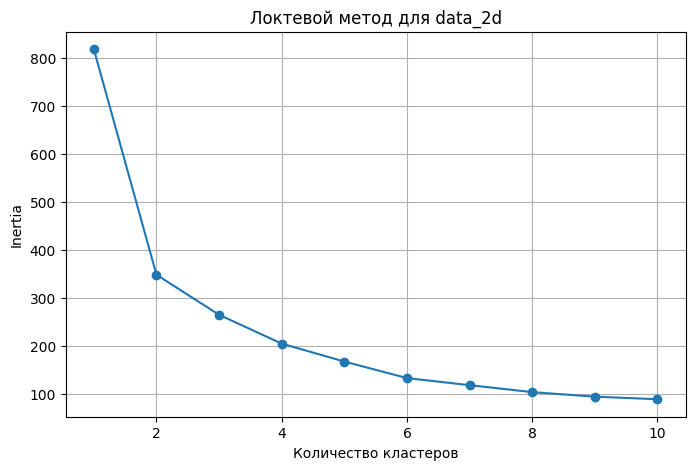

In [10]:
# Ліктевий метод для датасета 2d
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias_2d = [] # Список для хранения ошибок для каждого количества кластеров

K_2d = range(1, 11) # K-means c кластерами от 1 до 10

for k in K_2d:
    kmeans_2d = KMeans(n_clusters=k, random_state=42) # Создание K-means; n_clusters=k — количество кластеров; random_state=42 — фиксирует случайность
    kmeans_2d.fit(X_2d) # Обучение модели
    inertias_2d.append(kmeans_2d.inertia_) # inertia_ насколько далеко точки находятся от центров своих кластеров

print(inertias_2d)

plt.figure(figsize=(8, 5))
plt.plot(K_2d, inertias_2d, marker='o') # marker='o' рисует кружочки в каждой точке
plt.xlabel('Количество кластеров')
plt.ylabel('Inertia')
plt.title('Локтевой метод для data_2d')
plt.grid(True) # Добавляет сетку
plt.show()

In [11]:
# Висновок:
# За результатами ліктьового методу значення inertia різко зменшується до k=2. 
# Після цього додавання нових кластерів дає значно менший приріст якості кластеризації. 
# Тому оптимальну кількість кластерів обрано рівною 2

In [12]:
# Фінальна кластеризація датасета 2d
kmeans_2d = KMeans(n_clusters=2, random_state=42)
clusters_2d = kmeans_2d.fit_predict(X_2d)
clusters_2d

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1], dtype=int32)

In [13]:
# добавляем номера кластеров в DataFrame
df_2d['cluster'] = clusters_2d
df_2d

,0,1,2,cluster
0,0.0,-0.768716,0.460860,0
1,0.0,2.687848,2.366961,1
2,0.0,-0.201379,0.470430,0
3,0.0,0.608496,1.225400,0
4,0.0,-0.082282,1.137218,0
...,...,...,...,...
195,1.0,0.629144,4.378584,1
196,1.0,-0.723824,5.361801,1
197,1.0,1.346107,2.333476,0
198,1.0,3.608219,3.411546,1


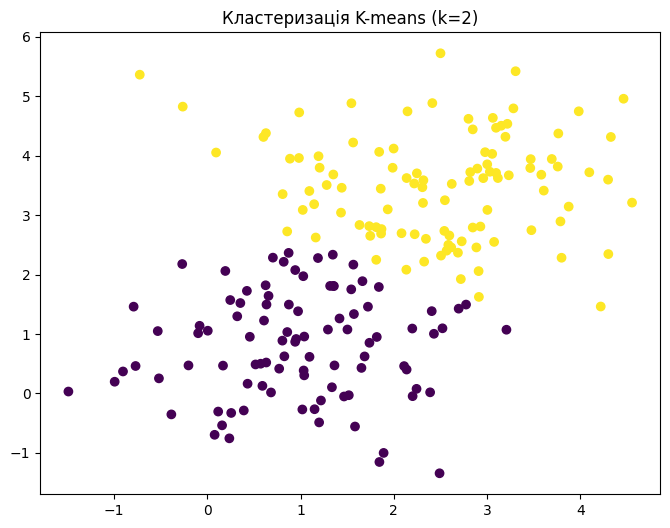

In [14]:
# Визуализация кластеров датасета 2d
plt.figure(figsize=(8, 6))
plt.scatter(
    X_2d.iloc[:, 0],
    X_2d.iloc[:, 1],
    c=clusters_2d, # цвета точек по номерам кластеров
    cmap='viridis' # цветовая схема
)

plt.title('Кластеризація K-means (k=2)')
plt.show()

In [16]:
# для визуализации кластеров делаем понижение размерности до 2 признаков с помощью PCA.
# Сжать 784 признака до двух новых признаков, сохранив как можно больше информации

from sklearn.decomposition import PCA

# Уменьшаем размерность 784 -> 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_mnist)

X_pca

array([[-2.80486482e+02,  4.49269976e+02],
       [-7.18967422e+01, -1.04576290e+03],
       [-9.67814869e+02, -3.48409939e+02],
       [ 1.05444083e+03, -3.53074238e+02],
       [ 4.19034836e+02,  6.73061269e+02],
       [-1.00109002e+03, -3.07090297e+02],
       [-6.25185584e+01,  4.24893839e+02],
       [-1.71806064e+02,  4.31910849e+02],
       [ 1.83552441e+02,  1.73273148e+02],
       [ 9.03220021e+01,  5.56249931e+02],
       [ 9.52889667e+02, -1.00680180e+03],
       [ 3.60421690e+02, -3.30783311e+02],
       [ 3.26899297e+00,  9.38919227e+02],
       [ 1.08169514e+03, -3.53655562e+02],
       [-1.11412006e+03, -4.16227581e+02],
       [ 1.54833008e+02, -6.37226437e+02],
       [ 4.01432843e+02,  9.30955613e+02],
       [-4.36226534e-01,  3.95261085e+02],
       [ 1.41970168e+02, -4.59309817e+02],
       [ 5.61905312e+01,  7.65661946e+02],
       [-2.65475769e+02,  3.43563078e+02],
       [ 3.14990133e+02, -1.20808254e+02],
       [-2.11028440e+01,  1.66111975e+02],
       [-8.

[300102522.29205936, 205957075.0049117, 102776349.27214044, 79139663.37705624, 59910876.82486518, 49100118.73630145, 43052740.90637407, 36772080.33781047, 34185440.690522306, 31242192.993068118]


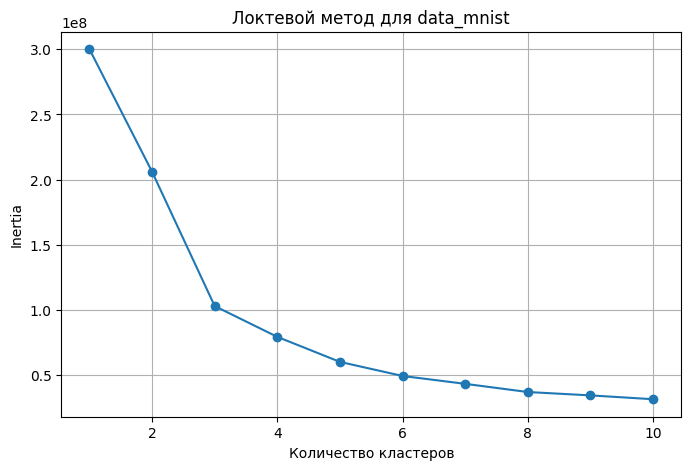

In [17]:
# Ліктевий метод для датасета mnist

inertias_mnist = [] # Список для хранения ошибок для каждого количества кластеров

K_mnist = range(1, 11) # K-means c кластерами от 1 до 10

for k in K_mnist:
    kmeans_mnist = KMeans(n_clusters=k, random_state=42) # Создание K-means; n_clusters=k — количество кластеров; random_state=42 — фиксирует случайность
    kmeans_mnist.fit(X_pca) # Обучение модели
    inertias_mnist.append(kmeans_mnist.inertia_) # inertia_ насколько далеко точки находятся от центров своих кластеров

print(inertias_mnist)

plt.figure(figsize=(8, 5))
plt.plot(K_mnist, inertias_mnist, marker='o') # marker='o' рисует кружочки в каждой точке
plt.xlabel('Количество кластеров')
plt.ylabel('Inertia')
plt.title('Локтевой метод для data_mnist')
plt.grid(True) # Добавляет сетку
plt.show()

In [104]:
# Висновок:
# Після зменшення розмірності даних за допомогою PCA до двох компонент
# методом ліктя визначено оптимальну кількість кластерів k = 3.

In [18]:
# Фінальна кластеризація датасета mnist
kmeans_mnist = KMeans(n_clusters=3, random_state=42)
clusters_mnist = kmeans_mnist.fit_predict(X_pca)
clusters_mnist

array([2, 0, 1, 0, 2, 1, 2, 2, 2, 2, 0, 0, 2, 0, 1, 0, 2, 2, 0, 2, 2, 0,
       2, 1, 2, 0, 2, 2, 0, 1, 1, 1, 0, 0, 2, 0, 2, 1, 1, 1, 1, 2, 2, 1,
       1, 0, 1, 1, 2, 2, 1, 0, 2, 0, 0, 0, 2, 1, 2, 1, 2, 0, 2, 1, 2, 1,
       0, 2, 0, 0, 2, 0, 0, 1, 1, 2, 1, 2, 1, 2, 2, 0, 0, 2, 2, 2, 2, 0,
       2, 1, 0, 2, 1, 0, 1, 2, 1, 1, 0, 2, 1, 0, 2, 2, 2, 2, 0, 1, 2, 2,
       0, 1, 1, 2, 1, 1, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 2, 0, 0,
       0, 2, 2, 1, 0, 1, 0, 2, 1, 2, 2, 1, 2, 1, 2, 0, 0, 1, 2, 2, 1, 0,
       1, 2, 2, 0, 0, 1, 2, 0, 0, 2, 2, 0, 2, 1, 1, 2, 2, 2, 0, 0, 1, 1,
       1, 2, 1, 0, 1, 0, 1, 0, 0, 2, 0, 0, 0, 1, 1, 1, 0, 2, 0, 1, 1, 1,
       2, 0, 0, 0, 1, 1, 1, 1, 2, 0, 0, 2, 2, 1, 2, 1, 2, 0, 1, 1, 1, 1,
       2, 0, 0, 2, 1, 0, 2, 2, 1, 1, 1, 1, 0, 2, 1, 2, 1, 1, 2, 1, 0, 0,
       0, 2, 1, 1, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 1, 1, 0, 0, 2, 1, 2, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 1, 2, 2, 2, 1, 2, 0, 1, 0, 2, 1, 1, 2, 1,
       1, 2, 1, 0, 2, 0, 2, 2, 0, 2, 0, 0, 0, 1, 1,

In [20]:
# добавляем номера кластеров в DataFrame
df_mnist['cluster'] = clusters_mnist
df_mnist

,0,1,2,3,4,5,6,7,8,9,...,776,777,778,779,780,781,782,783,784,cluster
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
496,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
497,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


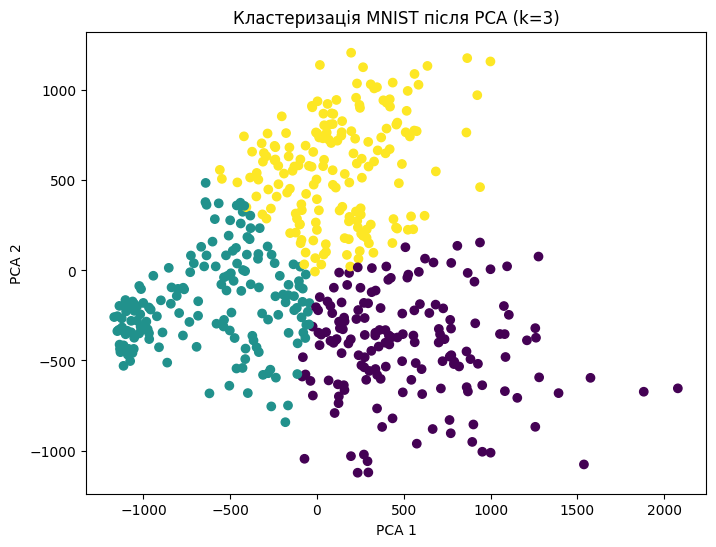

In [21]:
# Визуализация кластеров после PCA для датасета mnist
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters_mnist, # цвета точек по номерам кластеров
    cmap='viridis' # цветовая схема
)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Кластеризація MNIST після PCA (k=3)')
plt.show()